# Helper functions to convert vector-raster representations

These are common functions used to convert between representations such as `Vector` and `Raster`. They use basically GeoPandas, Shapely, and Rasterio frameworks to provide a simple conversion API.


Ready? Let’s dive in! 🚀

In [1]:
from urban_mapper.utils.helpers import to_point, to_line, to_polygon, raster_to_polygon, vector_to_raster
import matplotlib.pyplot as plt

COLOR_PALETTE = plt.cm.tab20c
COLOR_NUMBER = 20

## Simple dataset with MultiPolygons

Note: the following dataset was retrieved from [geodatasets](https://geodatasets.readthedocs.io/en/latest/introduction.html) and saved here to make the process easy.

In [2]:
import geopandas as gpd

gdf_nybb = gpd.read_file("data_test/geodatasets.nybb.geojson")

gdf_nybb

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


<Axes: >

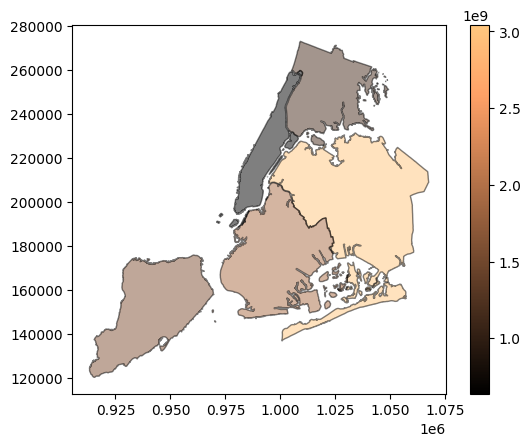

In [3]:
gdf_nybb.plot(column="Shape_Area", legend=True, cmap = "copper", alpha=0.5, edgecolor="k")

### 1 Converting MultiPolygons to other vector structures

[]

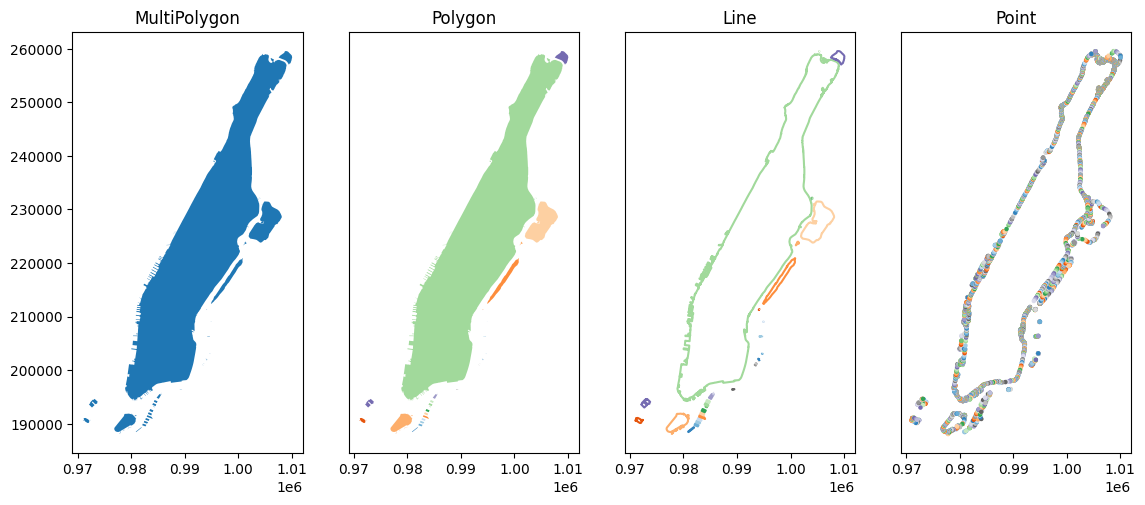

In [4]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(1366 / 100, 768 / 100), dpi = 100)

gdf_nybb_manhattan = gdf_nybb[gdf_nybb.BoroCode == 1]

gdf_nybb_manhattan.plot(ax=axes[0])
axes[0].set_title('MultiPolygon')

polygons = to_polygon(gdf_nybb_manhattan)
colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(polygons.shape[0])]
polygons.plot(ax=axes[1], color = colors)
axes[1].set_title('Polygon')
axes[1].set_yticks([])

lines = to_line(gdf_nybb_manhattan)
colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(lines.shape[0])]
lines.plot(ax=axes[2], color = colors)
axes[2].set_title('Line')
axes[2].set_yticks([])

points = to_point(gdf_nybb_manhattan)
colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(points.shape[0])]
points.plot(ax=axes[3], color = colors, markersize = 5)
axes[3].set_title('Point')
axes[3].set_yticks([])

## Simple dataset with Polygons

Note: the following dataset was retrieved from [geodatasets](https://geodatasets.readthedocs.io/en/latest/introduction.html) and saved here to make the process easy.

In [5]:
gdf_airbnb = gpd.read_file("data_test/geodatasets.geoda.airbnb.geojson")

gdf_airbnb.head()

,community,shape_area,shape_len,AREAID,response_r,accept_r,rev_rating,price_pp,room_type,num_spots,...,crowded,dependency,without_hs,unemployed,income_pc,harship_in,num_crimes,num_theft,population,geometry
0,DOUGLAS,46004621.1581,31027.0545098,35,98.771429,94.514286,87.777778,78.157895,1.789474,38,...,1.8,30.7,14.3,18.2,23791,47,5013,1241,18238,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,OAKLAND,16913961.0408,19565.5061533,36,99.200000,90.105263,88.812500,53.775000,1.850000,20,...,1.3,40.4,18.4,28.7,19252,78,1306,311,5918,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,FULLER PARK,19916704.8692,None,37,68.000000,NaN,91.750000,84.000000,1.833333,6,...,3.2,44.9,26.6,33.9,10432,97,1764,383,2876,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,GRAND BOULEVARD,48492503.1554,28196.8371573,38,94.037037,83.615385,92.750000,119.533333,1.533333,30,...,3.3,39.5,15.9,24.3,23472,57,6416,1428,21929,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,KENWOOD,29071741.9283,23325.1679062,39,92.542857,88.142857,90.656250,77.991453,1.615385,39,...,2.4,35.4,11.3,15.7,35911,26,2713,654,17841,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


<Axes: >

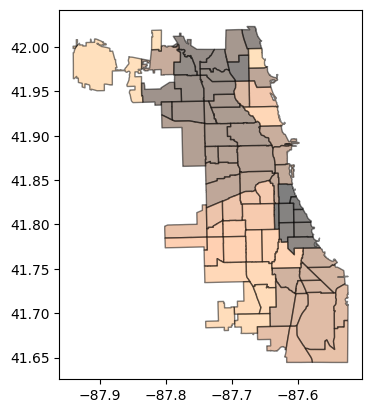

In [6]:
gdf_airbnb.plot(legend=True, cmap = "copper", alpha=0.5, edgecolor="k")

### 1 Converting Polygons to other vector structures

[]

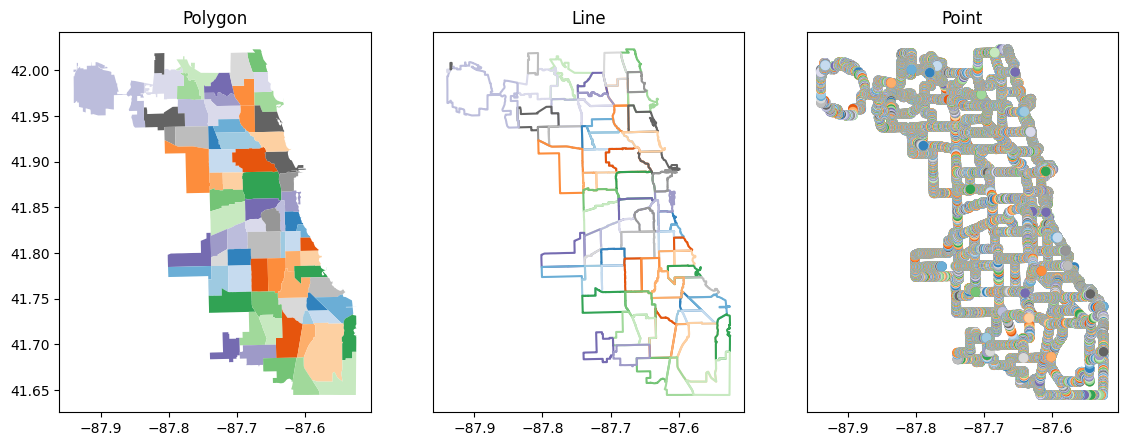

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(1366 / 100, 768 / 100), dpi = 100)

colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(gdf_airbnb.shape[0])]
gdf_airbnb.plot(ax=axes[0], color = colors)
axes[0].set_title('Polygon')

lines = to_line(gdf_airbnb)
colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(lines.shape[0])]
lines.plot(ax=axes[1], color = colors)
axes[1].set_title('Line')
axes[1].set_yticks([])

points = to_point(gdf_airbnb)
colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(points.shape[0])]
points.plot(ax=axes[2], color = colors)
axes[2].set_title('Point')
axes[2].set_yticks([])

## Simple dataset with MultiLines

In [8]:
import urban_mapper as um

layer = um.UrbanMapper().urban_layer.with_type("streets_roads").from_place("Manhattan, New York, New York, USA", network_type="drive").build()
gdf_speed_humps = um.UrbanMapper().loader.from_huggingface("oscur/NYC_speed_humps").with_columns(geometry_column="the_geom").load()
gdf_speed_humps = um.UrbanMapper().imputer.with_type("SimpleGeoImputer").on_columns(geometry_column="the_geom").transform(gdf_speed_humps, layer)
gdf_speed_humps = um.UrbanMapper().filter.with_type("BoundingBoxFilter").transform(gdf_speed_humps, layer)

gdf_speed_humps.head()

/home/fabio/Documents/Python/oscur/lib/python3.10/site-packages/osmnx/convert.py:542: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  dupes = edges[mask].dropna(subset=["geometry"])


,the_geom,OBJECTID,on_street,from_stree,to_street,humps,date_insta,Shape_STLe,longitude,latitude
89,"MULTILINESTRING ((-73.92871 40.77581, -73.9290...",90,12 STREET,27 AVENUE,SHORE BOULEVARD,1,12/19/2006,866.507547,-73.928707,40.775815
121,"MULTILINESTRING ((-73.93918 40.75918, -73.9400...",122,13 STREET,37 AVENUE,38 AVENUE,1,04/20/2010,550.100753,-73.939178,40.759175
162,"MULTILINESTRING ((-73.9282 40.77491, -73.92834...",163,14 STREET,ASTORIA PK. SOUTH,27 AVENUE,2,08/20/2014,596.286266,-73.928196,40.774910
274,"MULTILINESTRING ((-73.92642 40.77502, -73.9268...",275,18 STREET,26 AVENUE,25 ROAD,1,08/30/2018,366.312785,-73.926415,40.775021
275,"MULTILINESTRING ((-73.92686 40.77418, -73.9269...",276,18 STREET,26 ROAD,26 AVENUE,1,08/30/2018,384.699697,-73.926862,40.774185


<Axes: >

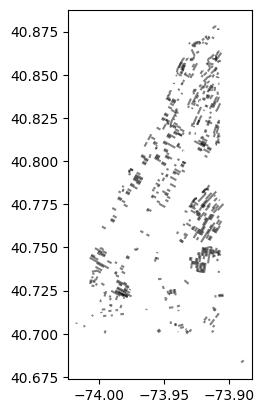

In [9]:
gdf_speed_humps.plot(legend=True, cmap = "copper", alpha=0.5, edgecolor="k")

### 1 Converting MultiLines to other vector structures

[]

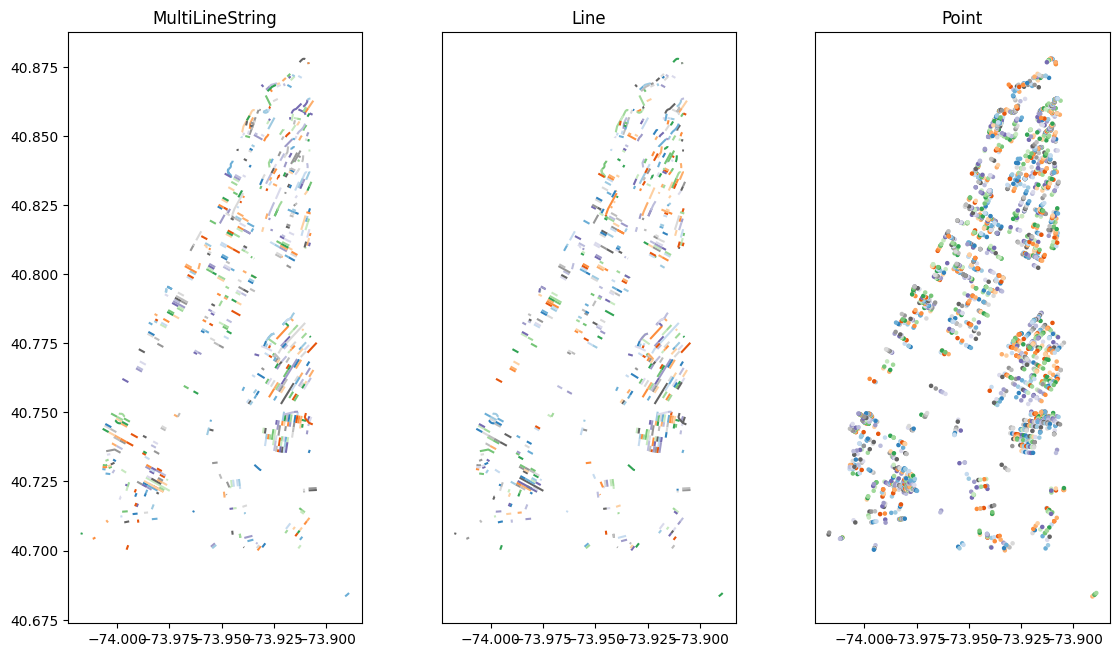

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(1366 / 100, 768 / 100), dpi = 100)

colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(gdf_speed_humps.shape[0])]
gdf_speed_humps.plot(ax=axes[0], color = colors)
axes[0].set_title('MultiLineString')

lines = to_line(gdf_speed_humps)
colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(lines.shape[0])]
lines.plot(ax=axes[1], color = colors)
axes[1].set_title('Line')
axes[1].set_yticks([])

points = to_point(gdf_speed_humps)
colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(points.shape[0])]
points.plot(ax=axes[2], color = colors, markersize = 5)
axes[2].set_title('Point')
axes[2].set_yticks([])

## Simple dataset with Lines

`Note: I didn't find a dataset only with Lines. Therefore, I loaded a MultiLines dataset and converted it to Lines with one of the helper functions`

In [11]:
gdf_rivers = gpd.read_file("data_test/geodatasets.eea.large_rivers.geojson")
gdf_rivers = to_line(gdf_rivers)

gdf_rivers

,NAME,Shape_Leng,geometry,geometry2line
0,Danube,2.770357e+06,"MULTILINESTRING ((4185683.29 2775788.04, 41861...","LINESTRING (4185683.2895 2775788.0395, 4186108..."
1,Danube,2.770357e+06,"MULTILINESTRING ((4185683.29 2775788.04, 41861...","LINESTRING (5791282.2613 2639994.038, 5792449...."
2,Danube,2.770357e+06,"MULTILINESTRING ((4185683.29 2775788.04, 41861...","LINESTRING (5791282.2613 2639994.038, 5810560...."
3,Danube,2.770357e+06,"MULTILINESTRING ((4185683.29 2775788.04, 41861...","LINESTRING (5792449.3772 2640904.0201, 5801176..."
4,Danube,2.770357e+06,"MULTILINESTRING ((4185683.29 2775788.04, 41861...","LINESTRING (5792449.3772 2640904.0201, 5800536..."
...,...,...,...,...
60,Kemijoki,4.651644e+05,"MULTILINESTRING ((4986013.832 4812271.498, 498...","LINESTRING (5000940.0119 4829919.3043, 5000940..."
61,Kemijoki,4.651644e+05,"MULTILINESTRING ((4986013.832 4812271.498, 498...","LINESTRING (5064907.9273 4896255.5523, 5065158..."
62,Kemijoki,4.651644e+05,"MULTILINESTRING ((4986013.832 4812271.498, 498...","LINESTRING (5064907.9273 4896255.5523, 5065158..."
63,Kemijoki,4.651644e+05,"MULTILINESTRING ((4986013.832 4812271.498, 498...","LINESTRING (5117378.4589 5040717.9466, 5117378..."


### 1. Converting Lines to other vector structures

[]

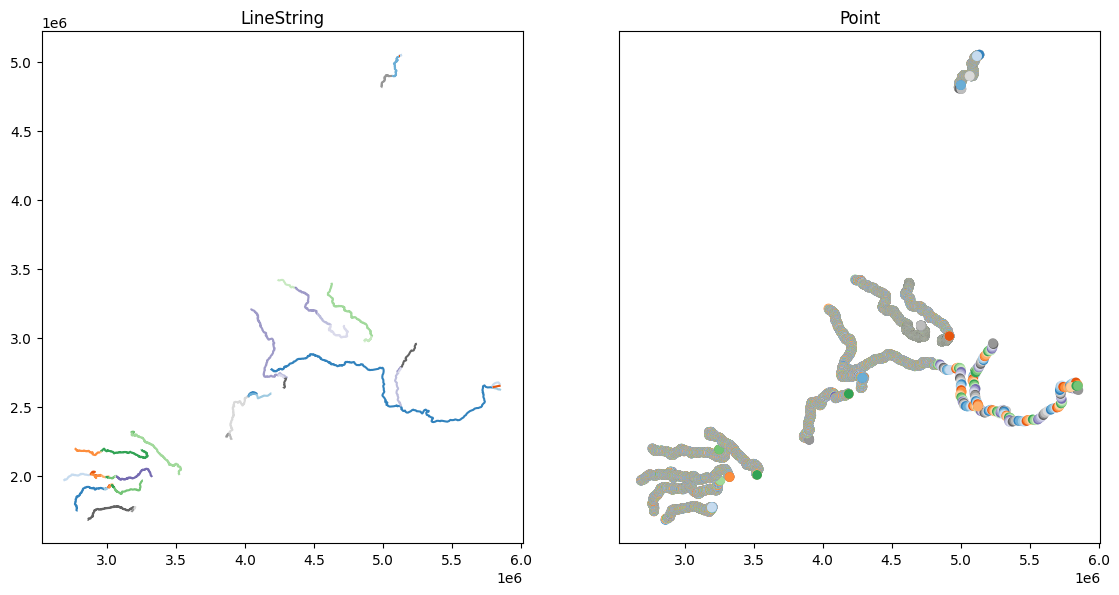

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(1366 / 100, 768 / 100), dpi = 100)

colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(gdf_rivers.shape[0])]
gdf_rivers.plot(ax=axes[0], color=colors, aspect="equal")
axes[0].set_title('LineString')

points = to_point(gdf_rivers)
colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(points.shape[0])]
points.plot(ax=axes[1], color=colors, aspect="equal")
axes[1].set_title('Point')
axes[1].set_yticks([])

## Simple dataset with MultiPoints

`Note: I didn't find a dataset only with MultiPoints. Therefore, I loaded a Points dataset and converted it to MultiPoints`

In [13]:
gdf_cleveland = gpd.read_file("data_test/geodatasets.geoda.cleveland.geojson")

gdf_cleveland

,unique_id,parcel,x,y,sale_price,tract10int,Quarter,year1,yrquarter,geometry
0,1183,002-02-036,2177340,663165,235500,101200,4,2015,154,POINT (2177340 663165)
1,1198,002-02-053,2177090,662872,65000,101200,4,2015,154,POINT (2177090 662872)
2,1516,002-14-053,2182100,663462,92000,103500,4,2015,154,POINT (2182100 663462)
3,1606,002-15-038,2181090,663162,5000,103400,4,2015,154,POINT (2181090 663162)
4,1612,002-15-043,2181090,663380,116250,103400,4,2015,154,POINT (2181090 663380)
...,...,...,...,...,...,...,...,...,...,...
200,168544,511-08-074,2197940,651658,45000,196100,4,2015,154,POINT (2197940 651658)
201,168564,511-09-040,2197980,650820,48500,196100,4,2015,154,POINT (2197980 650820)
202,168720,511-13-007,2199300,650213,22000,196100,4,2015,154,POINT (2199300 650213)
203,168726,511-13-018,2199300,649849,41000,196100,4,2015,154,POINT (2199300 649849)


<Axes: >

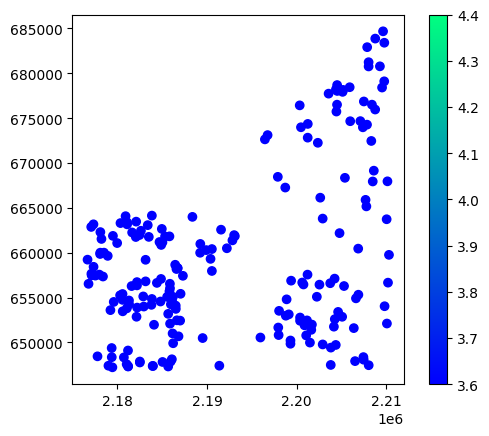

In [14]:
gdf_cleveland.plot(column="Quarter", legend=True, cmap = "winter")

### 1 Creating MultiPoints

In [15]:
from shapely import MultiPoint

synth_points = []

for idx, row in gdf_cleveland.geometry.get_coordinates().iterrows():
   synth_points.append([row.x, row.y])

synth_points = MultiPoint(synth_points)
synth_points = gpd.GeoSeries(synth_points)
synth_points = gpd.GeoDataFrame({"id": [1 for i in range(len(synth_points))]}, geometry = synth_points)

synth_points   

,id,geometry
0,1,"MULTIPOINT (2177340 663165, 2177090 662872, 21..."


### 2 Converting MultiPoints to other vector structures

[]

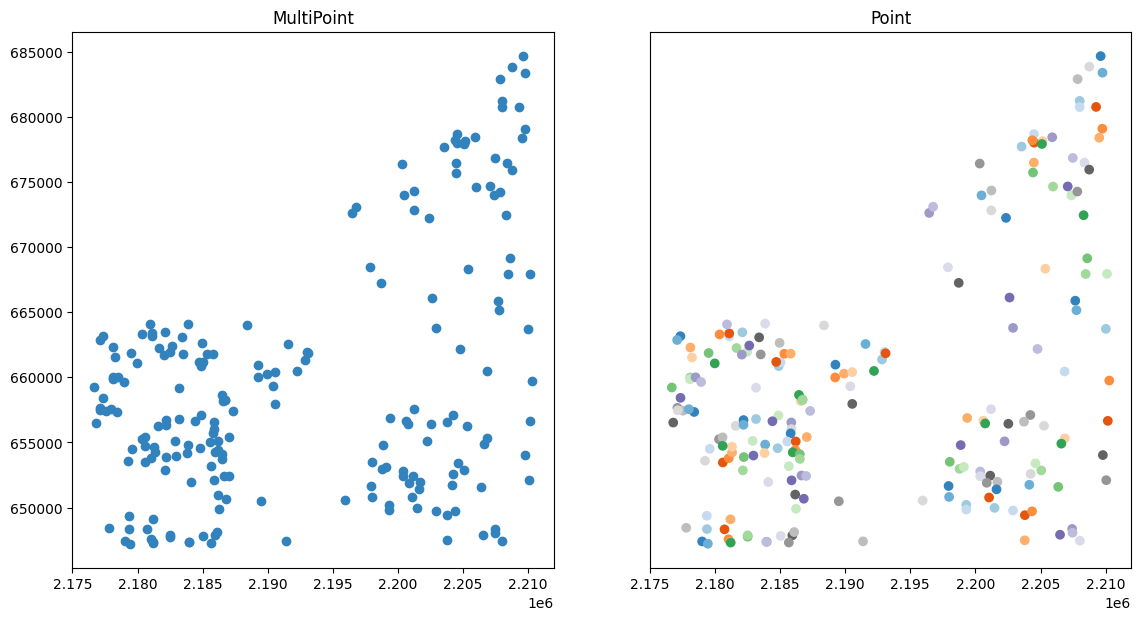

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(1366 / 100, 768 / 100), dpi = 100)


colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(synth_points.shape[0])]
synth_points.plot(ax=axes[0], color=colors)
axes[0].set_title('MultiPoint')

points = to_point(synth_points)
colors = [COLOR_PALETTE(idx % COLOR_NUMBER) for idx in range(points.shape[0])]
points.plot(ax=axes[1], color=colors)
axes[1].set_title('Point')
axes[1].set_yticks([])

## Converting data to a grid of polygons

<Axes: >

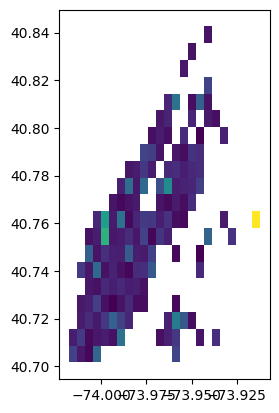

In [4]:
import urban_mapper as um
from urban_mapper.utils.helpers import grid_from_data

gdf_taxi =  um.UrbanMapper().loader.from_huggingface("oscur/taxisvis1M", number_of_rows=1000).with_columns(longitude_column="pickup_longitude", latitude_column="pickup_latitude").load()

## Manhattan bounds
gdf_taxi_grid = grid_from_data(gdf_taxi, bounds=[-74.0180549,  40.7015518, -73.9076185,  40.8778412], size=(25, 25), column_map="trip_distance")

gdf_taxi_grid.plot(column="value")

## Vector-Raster conversions

In [17]:
## https://rasterio.readthedocs.io/en/stable/quickstart.html
## https://rasterio.readthedocs.io/en/stable/topics/plotting.html
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd

from rasterio.plot import show

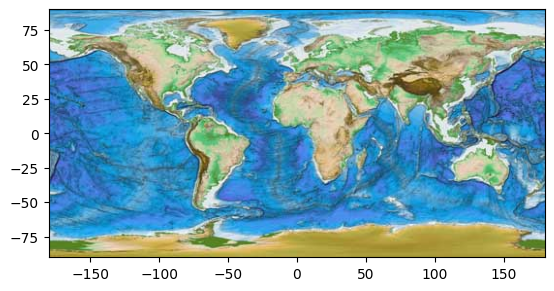

<Axes: >

In [18]:
## https://github.com/rasterio/rasterio/tree/main/tests/data
img = rasterio.open('data_test/world.rgb.tif')
show(img)

### 1 Converting raster to Polygons

In [19]:
gdf_raster = raster_to_polygon(img, reduce_with=None, band=None, clusters=None, aggregate_func=None)
gdf_raster

,value,geometry
0,76.0,"POLYGON ((-180 90, -180 89.29688, -179.29688 8..."
1,75.0,"POLYGON ((-179.29688 90, -179.29688 89.29688, ..."
2,73.0,"POLYGON ((-178.59375 90, -178.59375 89.29688, ..."
3,72.0,"POLYGON ((-177.89062 90, -177.89062 89.29688, ..."
4,74.0,"POLYGON ((-176.48438 90, -176.48438 89.29688, ..."
...,...,...
115017,168.0,"POLYGON ((176.48438 -89.29688, 176.48438 -90, ..."
115018,171.0,"POLYGON ((177.1875 -89.29688, 177.1875 -90, 17..."
115019,172.0,"POLYGON ((177.89062 -89.29688, 177.89062 -90, ..."
115020,170.0,"POLYGON ((178.59375 -89.29688, 178.59375 -90, ..."


<Axes: >

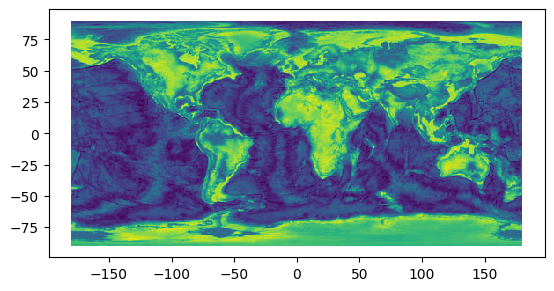

In [20]:
from matplotlib import colormaps as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=gdf_raster.value.min(), vmax=gdf_raster.value.max())
cmap = cm.get_cmap('viridis')
colors = [cmap(norm(d)) for d in gdf_raster.value]

gdf_raster.plot(color = colors)

### 2 Reducing number of extracted Polygons (quantization)

In [21]:
gdf_raster = raster_to_polygon(img, reduce_with="quantize", band=None, clusters=6, aggregate_func="max")
gdf_raster

,cluster,aggregated_value,geometry
0,1.0,48,"POLYGON ((-52.73438 90, -52.73438 89.29688, -5..."
1,2.0,56,"POLYGON ((-52.03125 90, -52.03125 89.29688, -4..."
2,1.0,46,"POLYGON ((156.79688 90, 156.79688 89.29688, 15..."
3,2.0,52,"POLYGON ((157.5 90, 157.5 89.29688, 158.90625 ..."
4,2.0,72,"POLYGON ((168.75 90, 168.75 88.59375, 171.5625..."
...,...,...,...
4251,3.0,152,"POLYGON ((-151.17188 -84.375, -151.17188 -85.0..."
4252,3.0,151,"POLYGON ((-146.95312 -85.78125, -146.95312 -87..."
4253,5.0,205,"POLYGON ((-96.32812 -85.78125, -96.32812 -86.4..."
4254,5.0,249,"POLYGON ((-10.54688 -71.71875, -10.54688 -72.4..."


<Axes: >

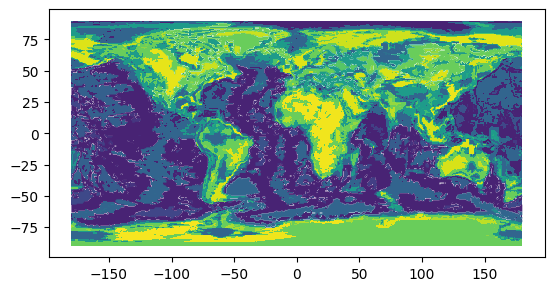

In [22]:
norm = mcolors.Normalize(vmin=gdf_raster.aggregated_value.min(), vmax=gdf_raster.aggregated_value.max())
cmap = cm.get_cmap('viridis')
colors = [cmap(norm(d)) for d in gdf_raster.aggregated_value]

gdf_raster.plot(color = colors)

### 3 Reducing number of extracted Polygons (clustering)

In [23]:
gdf_raster = raster_to_polygon(img, reduce_with="cluster", band=None, clusters=6, aggregate_func="max")
gdf_raster

,cluster,aggregated_value,geometry
0,2.0,76,"POLYGON ((-167.34375 90, -167.34375 89.29688, ..."
1,4.0,71,"POLYGON ((-165.9375 90, -165.9375 89.29688, -1..."
2,2.0,78,"POLYGON ((-163.82812 90, -163.82812 89.29688, ..."
3,4.0,75,"POLYGON ((-161.71875 90, -161.71875 89.29688, ..."
4,2.0,77,"POLYGON ((-156.79688 90, -156.79688 89.29688, ..."
...,...,...,...
3893,1.0,192,"POLYGON ((173.67188 -85.78125, 173.67188 -86.4..."
3894,1.0,195,"POLYGON ((-126.5625 -86.48438, -126.5625 -87.1..."
3895,1.0,241,"POLYGON ((-14.76562 -73.125, -14.76562 -73.828..."
3896,1.0,196,"POLYGON ((-161.71875 -87.1875, -161.71875 -87...."


<Axes: >

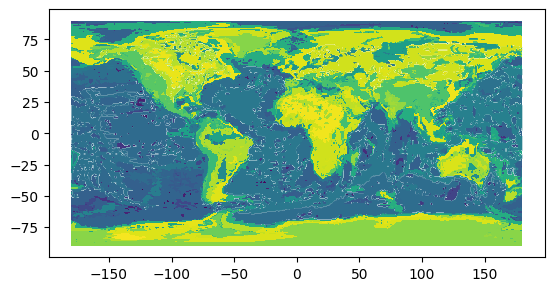

In [24]:
norm = mcolors.Normalize(vmin=gdf_raster.aggregated_value.min(), vmax=gdf_raster.aggregated_value.max())
cmap = cm.get_cmap('viridis')
colors = [cmap(norm(d)) for d in gdf_raster.aggregated_value]

gdf_raster.plot(color = colors)

### 4 Converting Vector to Raster

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def plot_aux(vector_data, raster_data, feature_column, norm = True, extent = None):
    scaler = MinMaxScaler()

    if norm:
        raster_data = scaler.fit_transform(raster_data)

    alpha = np.ones(raster_data.shape)
    alpha[raster_data == 0] = 0

    _, ax = plt.subplots(1, 2, figsize=(10, 10))

    vector_data.plot(ax = ax[0], column=feature_column, legend=False, cmap = "winter", aspect="equal")

    ax[1].imshow(raster_data, cmap='Reds', vmin=0, vmax=raster_data.max(), extent = extent, zorder = 1, alpha = alpha)
    ax[1].set_yticks([])

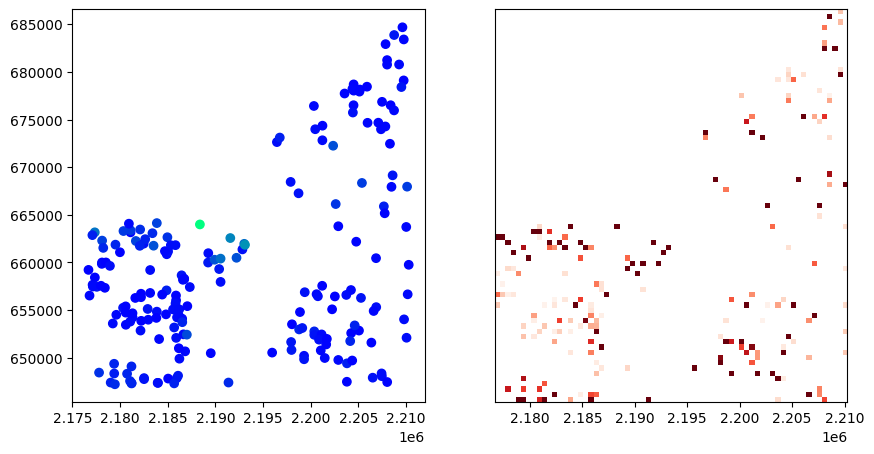

In [26]:
raster_cleveland, transform_cleveland, extent_cleveland = vector_to_raster(gdf_cleveland, "sale_price", resolution=500)
plot_aux(gdf_cleveland, raster_cleveland, "sale_price", norm = True, extent = extent_cleveland)

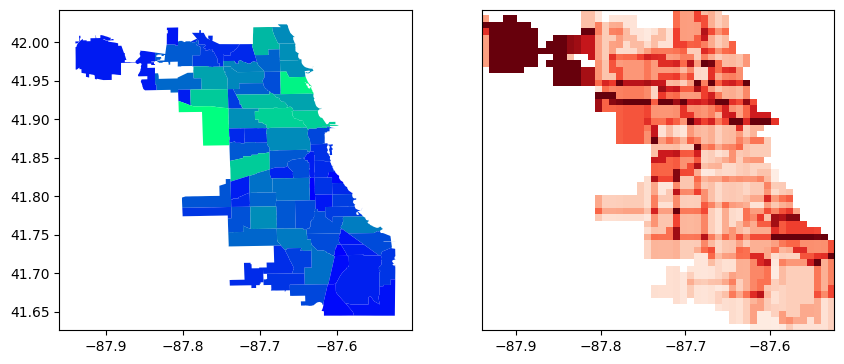

In [27]:
raster_aribnb, transform_aribnb, extent_aribnb = vector_to_raster(gdf_airbnb, "population", size=(50, 50))
plot_aux(gdf_airbnb, raster_aribnb, "population", norm = True, extent = extent_aribnb)

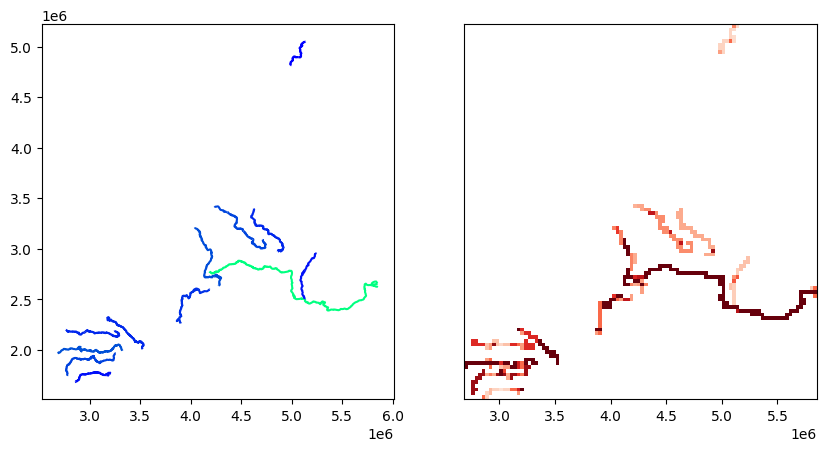

In [28]:
raster_river, transform_river, extent_river = vector_to_raster(gdf_rivers, "Shape_Leng", size=(100, 100))
plot_aux(gdf_rivers, raster_river, "Shape_Leng", norm = True, extent = extent_river)